## Creating synthetic data for 3D K-Means

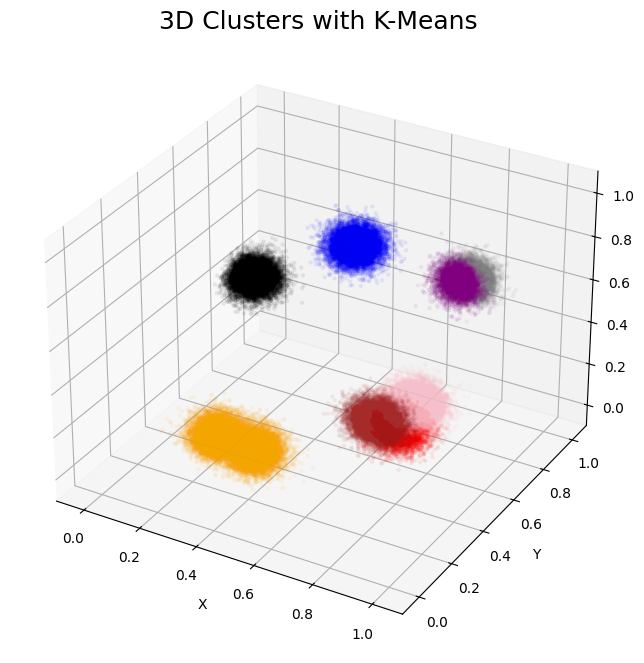

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Parameters
# -----------------------------
n_points = 98000
clusters = 8

# -----------------------------
# Generate 3D data
# -----------------------------
points, y_true = make_blobs(
    n_samples=n_points,
    centers=clusters,
    n_features=3,
    cluster_std=0.04,
    random_state=7,
    center_box=(0, 1.0)
)

# only positive values and 3 decimals
points = np.round(np.abs(points), 3)

# save CSV
np.savetxt(f"{n_points}_data_3d.csv", points, delimiter=",", fmt="%.3f")

# -----------------------------
# DataFrame
# -----------------------------
points_df = pd.DataFrame({
    "x": points[:, 0],
    "y": points[:, 1],
    "z": points[:, 2]
    })

# -----------------------------
# KMeans clustering
# -----------------------------
kmeans = KMeans(n_clusters=clusters, n_init="auto", random_state=7)
kmeans.fit(points)

points_df["cluster"] = kmeans.labels_

# -----------------------------
# 3D Plot
# -----------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ["red", "blue", "orange", "black",
          "purple", "pink", "brown", "gray"]

for cluster in range(clusters):

    cluster_points = points_df[points_df["cluster"] == cluster]

    ax.scatter(
        cluster_points["x"],
        cluster_points["y"],
        cluster_points["z"],
        marker="o",
        s=5,
        color=colors[cluster],
        alpha=0.05
    )


ax.set_title("3D Clusters with K-Means", fontsize=18)
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_zlim(-0.1, 1.1)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

## Creating synthetic data for 2D K-Means

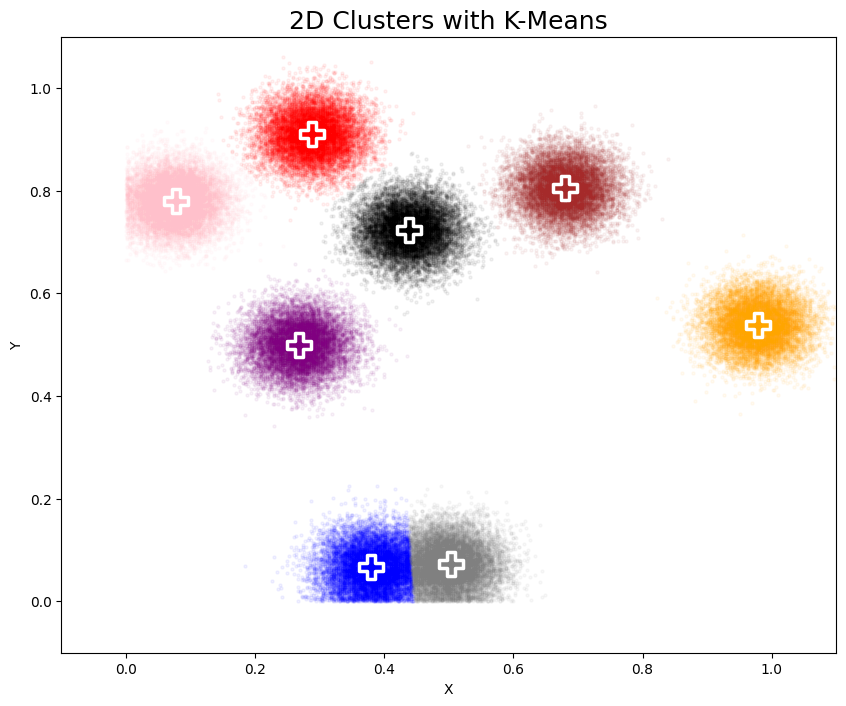

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Parameters
# -----------------------------
n_points = 98000
clusters = 8

# -----------------------------
# Generate 2D data
# -----------------------------
points, y_true = make_blobs(
    n_samples=n_points,
    centers=clusters,
    n_features=2,
    cluster_std=0.04,
    random_state=7,
    center_box=(0, 1.0)
)

# only positive values and 3 decimals
points = np.round(np.abs(points), 3)

# save CSV
np.savetxt(f"{n_points}_data_2d.csv", points, delimiter=",", fmt="%.3f")

# -----------------------------
# DataFrame
# -----------------------------
points_df = pd.DataFrame({
    "x": points[:, 0],
    "y": points[:, 1]
    })

# -----------------------------
# KMeans clustering
# -----------------------------
kmeans = KMeans(n_clusters=clusters, n_init="auto", random_state=7)
kmeans.fit(points)

points_df["cluster"] = kmeans.labels_

# -----------------------------
# 2D Plot
# -----------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

colors = ["red", "blue", "orange", "black",
          "purple", "pink", "brown", "gray"]

for cluster in range(clusters):

    cluster_points = points_df[points_df["cluster"] == cluster]

    ax.scatter(
        cluster_points["x"],
        cluster_points["y"],
        marker="o",
        s=5,
        color=colors[cluster],
        alpha=0.05
    )

    # cluster centers
    ax.scatter(
        kmeans.cluster_centers_[cluster][0],
        kmeans.cluster_centers_[cluster][1],
        marker="P",
        s=300,
        color=colors[cluster],
        edgecolors="white",
        linewidths=2.5
    )

ax.set_title("2D Clusters with K-Means", fontsize=18)
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)


ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()